# 트리 모델로 위험도 지표 검증

위험도 지표 A·B·C는 법 기준과 논리로 만든 규칙 점수라 정답이 없다. 이 노트북은 지표 바깥의 결과(서울 보행자 사고다발지)를
정답으로 두고, **지표를 이루는 요소가 사고 발생 위치를 설명하는지** 트리 모델로 확인한다. 결정 기록은 `codex&claude.md` §16.34.

- 1행 = 서울 교차로 1개 (교차로관리번호로 묶은 횡단보도 그룹, 7,592개)
- 정답 y = 교차로 중심 반경 100m 안에 보행자 사고다발지가 있으면 1 (50·200m는 민감도)
- 입력 X = A 요소 · C 요소 · B 요소 + 통제 변수(보행량 대리)
- A의 부족 +1 점수는 사고다발지로 만든 값이라 입력에서 뺀다(누수)
- 모델: HistGradientBoosting(주), RandomForest(비교), 로지스틱 회귀(기준선), 깊이 3 결정 트리(규칙 설명용)
- 평가: 자치구 단위 공간 교차검증(5-fold). 가까운 교차로는 같은 사고다발지를 공유하므로 무작위 분할은 성능을 부풀린다.

이 검증이 할 수 **없는** 것: 시각장애인에게 맞는 지표인지 증명(사고 데이터가 시각장애인 전용이 아님), 인과 판단,
두 학교 결과 변경(A·B·C는 합치지 않고, 모델 예측을 새 점수로 쓰지 않음), 구간 단위 B·C 검증(정답이 교차로 단위).

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.metrics import average_precision_score, roc_auc_score
import ml_tree_validation as m
importlib.reload(m)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)
FIG = Path('figures/tree_model'); FIG.mkdir(parents=True, exist_ok=True)
GRAY, BLUE = '#9aa0a6', '#2a6fdb'

## 1. 교차로 테이블

`ml_tree_validation.build_table()`이 만든다(경사 계산 때문에 4분쯤 걸려서 `data/tree_model/seoul_intersections.csv`에 저장해 두고 읽는다).

| 묶음 | 변수 | 만든 방법 |
|---|---|---|
| A 요소 | 지원점수_최대 | 횡단보도별 지원점수(보행등+음향 0 / 보행등만 1 / 보행등 없음 2, 불일치는 2)의 최댓값 |
| | 보행등_비율 | 보행등 있는 횡단보도 비율 |
| | 음향_유무 | 음향신호기 15m 배정 규칙(H5)으로 하나라도 있으면 1 |
| | 횡단보도수 | 교차로에 속한 횡단보도 수 |
| C 요소 | 횡단단수_최대 | 일단 1 / 이단 2 / 삼단 3 |
| | 대각선_유무 | 대각선횡단보도가 있으면 1 |
| B 요소 | 경사_60m | 교차로 중심을 지나는 60m 선 4방향(0/45/90/135도) 경사의 최댓값(%). 지표 B와 같은 등고선·표고점, 같은 보간 |
| 통제 | 정류소수_100m | 반경 100m 버스정류소 수 |
| | 승하차_200m | 반경 200m 정류소의 2026년 8월 하루 평균 승하차 인원 합 |
| | 교차로수_300m | 반경 300m 다른 교차로 수(도심 밀도) |

지하철역 좌표는 폴더에 없어 넣지 않았다. 장애인편의시설 목록은 대부분 다세대주택·아파트 같은 설치 대상 건물이라 넣지 않았다.

In [2]:
path = m.OUT_DIR / 'seoul_intersections.csv'
g = m.load_table() if path.exists() else m.build_table()
FULL = m.FEATURES_CTRL + m.FEATURES_A + m.FEATURES_C + m.FEATURES_B
ACB = m.FEATURES_A + m.FEATURES_C + m.FEATURES_B
g[FULL] = g[FULL].astype(float)
y = g['y_100m'].to_numpy()
groups = g['자치구'].to_numpy()
print(f'교차로 {len(g):,}개, 자치구 {g["자치구"].nunique()}개')
print('정답 1의 비율:', {r: f'{g[f"y_{r}m"].sum()}개 ({g[f"y_{r}m"].mean():.1%})' for r in m.LABEL_RADII})
print('결측:', g[FULL].isna().sum()[lambda s: s > 0].to_dict(), '(여의도 등 등고선이 거의 없는 평지. 트리 모델은 결측을 그대로 받고, RF·로지스틱은 중앙값으로 채움)')
g[FULL].describe().T.round(2)

교차로 7,592개, 자치구 25개
정답 1의 비율: {50: '216개 (2.8%)', 100: '553개 (7.3%)', 200: '1049개 (13.8%)'}
결측: {'경사_60m': 7} (여의도 등 등고선이 거의 없는 평지. 트리 모델은 결측을 그대로 받고, RF·로지스틱은 중앙값으로 채움)


,count,mean,std,min,25%,50%,75%,max
정류소수_100m,7592.0,1.69,1.42,0.0,0.00,2.00,2.00,10.00
승하차_200m,7592.0,3746.02,4726.10,0.0,994.48,2392.24,4727.65,54056.87
교차로수_300m,7592.0,5.71,2.68,0.0,4.00,6.00,7.00,17.00
지원점수_최대,7592.0,1.41,0.83,0.0,1.00,2.00,2.00,2.00
보행등_비율,7592.0,0.62,0.35,0.0,0.33,0.60,1.00,1.00
음향_유무,7592.0,0.70,0.46,0.0,0.00,1.00,1.00,1.00
횡단보도수,7592.0,2.87,1.55,1.0,2.00,3.00,4.00,13.00
횡단단수_최대,7592.0,1.85,0.36,1.0,2.00,2.00,2.00,3.00
대각선_유무,7592.0,0.04,0.20,0.0,0.00,0.00,0.00,1.00
경사_60m,7585.0,4.54,5.13,0.0,1.09,2.79,6.20,42.54


### 1-1. 정답 1과 0의 단순 비교

모델 전에 요소별로 사고다발지 근처 비율이 어떻게 다른지 본다. 보행량(승하차)이 크게 다르다는 점이 핵심이다.

In [3]:
display(g.groupby('y_100m')[FULL].median().T.rename(columns={0: '사고다발지 없음(중앙값)', 1: '있음(중앙값)'}).round(2))
for f in ['지원점수_최대', '음향_유무', '횡단단수_최대']:
    t = g.groupby(f)['y_100m'].agg(비율='mean', 교차로수='size')
    t['비율'] = t['비율'].map('{:.1%}'.format)
    display(t.T)

y_100m,사고다발지 없음(중앙값),있음(중앙값)
정류소수_100m,2.00,2.00
승하차_200m,2201.68,7314.97
교차로수_300m,5.00,6.00
지원점수_최대,2.00,2.00
보행등_비율,0.60,0.57
음향_유무,1.00,1.00
횡단보도수,3.00,3.00
횡단단수_최대,2.00,2.00
대각선_유무,0.00,0.00
경사_60m,2.84,2.26


지원점수_최대,0.0,1.0,2.0
비율,5.7%,5.7%,8.2%
교차로수,1675,1159,4758


음향_유무,0.0,1.0
비율,5.0%,8.3%
교차로수,2276,5316


횡단단수_최대,1.0,2.0,3.0
비율,3.4%,8.0%,0.0%
교차로수,1161,6430,1


## 2. 모델 비교 — 통제 변수만 vs 통제 + A·B·C 요소

같은 자치구 5-fold로 나눠 학습에 쓰지 않은 자치구의 교차로를 예측한다.
PR-AUC의 기준값(아무 정보 없이 찍을 때)은 정답 1의 비율 7.3%다.

In [4]:
cv = GroupKFold(n_splits=5)

def make_models():
    return {
        'HistGB': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                                 min_samples_leaf=40, class_weight='balanced', random_state=0),
        'RandomForest': make_pipeline(SimpleImputer(strategy='median'),
                                      RandomForestClassifier(500, min_samples_leaf=20, class_weight='balanced',
                                                             n_jobs=-1, random_state=0)),
        '로지스틱': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                              LogisticRegression(class_weight='balanced', max_iter=2000)),
    }

def cv_scores(features, label='y_100m'):
    yy = g[label].to_numpy()
    rows = []
    for name, model in make_models().items():
        for k, (tr, te) in enumerate(cv.split(g, yy, groups)):
            p = model.fit(g.iloc[tr][features], yy[tr]).predict_proba(g.iloc[te][features])[:, 1]
            rows.append({'모델': name, 'fold': k, 'PR-AUC': average_precision_score(yy[te], p),
                         'ROC-AUC': roc_auc_score(yy[te], p)})
    return pd.DataFrame(rows)

res = pd.concat([cv_scores(m.FEATURES_CTRL).assign(입력='통제만'),
                 cv_scores(FULL).assign(입력='통제 + A·B·C'),
                 cv_scores(ACB).assign(입력='A·B·C만')])
summary = res.groupby(['모델', '입력'])[['PR-AUC', 'ROC-AUC']].agg(['mean', 'min', 'max']).round(3)
summary

PR-AUC               ROC-AUC              
                          mean    min    max    mean    min    max
모델           입력                                                   
HistGB       A·B·C만      0.105  0.092  0.124   0.594  0.573  0.614
             통제 + A·B·C  0.274  0.202  0.307   0.798  0.787  0.806
             통제만         0.286  0.224  0.331   0.771  0.753  0.795
RandomForest A·B·C만      0.110  0.091  0.127   0.627  0.607  0.649
             통제 + A·B·C  0.295  0.203  0.343   0.818  0.793  0.837
             통제만         0.300  0.199  0.369   0.795  0.768  0.820
로지스틱         A·B·C만      0.135  0.081  0.228   0.646  0.597  0.691
             통제 + A·B·C  0.330  0.204  0.385   0.822  0.802  0.837
             통제만         0.331  0.222  0.386   0.814  0.802  0.827

fold별 PR-AUC 차이 — 5개 fold 중 A·B·C를 더해 좋아진 fold 수
                 평균  좋아진_fold
모델                           
HistGB       -0.012         1
RandomForest -0.005         3
로지스틱         -0.001         3


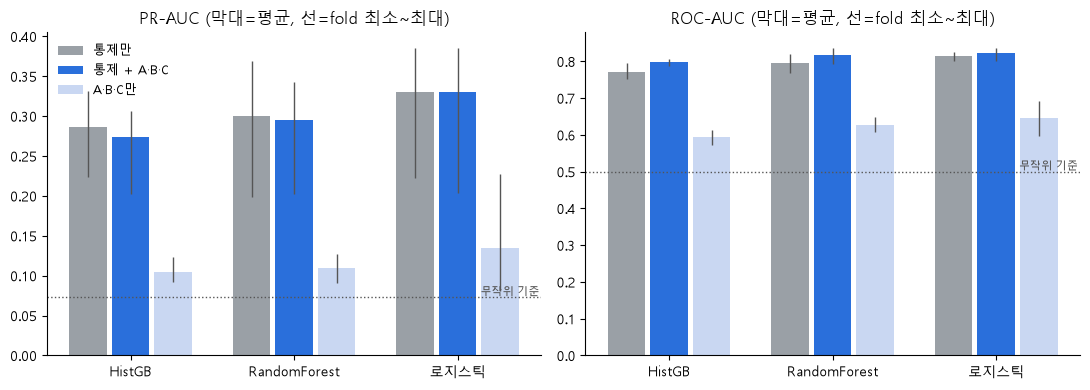

In [5]:
d = res.pivot_table(index=['모델', 'fold'], columns='입력', values='PR-AUC')
d['차이(통제+A·B·C − 통제만)'] = d['통제 + A·B·C'] - d['통제만']
print('fold별 PR-AUC 차이 — 5개 fold 중 A·B·C를 더해 좋아진 fold 수')
print(d.groupby('모델')['차이(통제+A·B·C − 통제만)'].agg(평균='mean', 좋아진_fold=lambda s: int((s > 0).sum())).round(3))

order = ['통제만', '통제 + A·B·C', 'A·B·C만']
colors = {'통제만': GRAY, '통제 + A·B·C': BLUE, 'A·B·C만': '#c9d7f2'}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, base in [(axes[0], 'PR-AUC', y.mean()), (axes[1], 'ROC-AUC', 0.5)]:
    mm = res.groupby(['모델', '입력'])[metric].agg(['mean', 'min', 'max']).reset_index()
    models = list(make_models())
    w = 0.26
    for j, inp in enumerate(order):
        s = mm[mm['입력'] == inp].set_index('모델').loc[models]
        x = np.arange(len(models)) + (j - 1) * w
        ax.bar(x, s['mean'], w - 0.03, color=colors[inp], label=inp)
        ax.errorbar(x, s['mean'], yerr=[s['mean'] - s['min'], s['max'] - s['mean']], fmt='none', ecolor='#555', lw=1)
    ax.axhline(base, color='#555', ls=':', lw=1)
    ax.text(len(models) - 0.5, base, ' 무작위 기준', va='bottom', ha='right', fontsize=8, color='#555')
    ax.set_xticks(range(len(models)), models); ax.set_title(f'{metric} (막대=평균, 선=fold 최소~최대)')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(FIG / '1_모델비교.png', dpi=150); plt.show()

## 3. 어떤 입력이 중요한가 — permutation importance

HistGB를 fold마다 학습하고, **학습에 쓰지 않은 자치구**에서 변수 하나씩 값을 섞었을 때 PR-AUC가 얼마나 떨어지는지 본다.
0 근처나 음수면 그 변수는 예측에 도움이 안 된다는 뜻이다. (트리 내부 중요도는 값이 다양한 연속 변수를 과대평가해서 쓰지 않는다.)

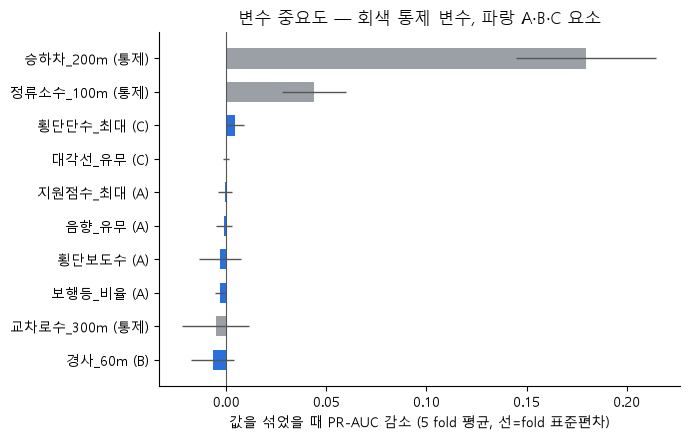

승하차_200m     0.1797
정류소수_100m    0.0439
횡단단수_최대      0.0043
대각선_유무      -0.0001
지원점수_최대     -0.0006
음향_유무       -0.0010
횡단보도수       -0.0030
보행등_비율      -0.0031
교차로수_300m   -0.0053
경사_60m      -0.0068
dtype: float64

In [6]:
imps = []
for tr, te in cv.split(g, y, groups):
    model = make_models()['HistGB'].fit(g.iloc[tr][FULL], y[tr])
    pi = permutation_importance(model, g.iloc[te][FULL], y[te], scoring='average_precision',
                                n_repeats=10, random_state=0)
    imps.append(pi.importances_mean)
imp = pd.DataFrame(imps, columns=FULL)
imp_s = imp.mean().sort_values()
group_of = {f: ('통제' if f in m.FEATURES_CTRL else 'A' if f in m.FEATURES_A else 'C' if f in m.FEATURES_C else 'B') for f in FULL}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp_s.index, imp_s.values, color=[GRAY if group_of[f] == '통제' else BLUE for f in imp_s.index], height=0.6)
ax.errorbar(imp_s.values, range(len(imp_s)), xerr=imp[imp_s.index].std().values, fmt='none', ecolor='#555', lw=1)
ax.axvline(0, color='#555', lw=0.8)
ax.set_yticks(range(len(imp_s)), [f'{f} ({group_of[f]})' for f in imp_s.index])
ax.set_xlabel('값을 섞었을 때 PR-AUC 감소 (5 fold 평균, 선=fold 표준편차)')
ax.set_title('변수 중요도 — 회색 통제 변수, 파랑 A·B·C 요소')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / '2_변수중요도.png', dpi=150); plt.show()
imp_s[::-1].round(4)

## 4. 방향 — 지표가 '위험하다'고 보는 쪽으로 사고 확률이 올라가는가

partial dependence: 다른 변수는 그대로 두고 한 변수만 바꿨을 때 모델의 평균 예측(사고다발지 근처일 확률)이 어떻게 변하는지.
전체 데이터로 학습한 HistGB 기준이다. 지표가 기대하는 방향은 아래와 같다.

| 변수 | 지표의 기대 방향 |
|---|---|
| 지원점수_최대 | 0 → 2로 갈수록 위험 ↑ (A) |
| 보행등_비율 | 높을수록 위험 ↓ (A) |
| 음향_유무 | 있으면 위험 ↓ (A) |
| 횡단단수_최대 | 이단이 일단보다 위험 ↑ (C) |
| 경사_60m | 가파를수록 위험 ↑ (B) |

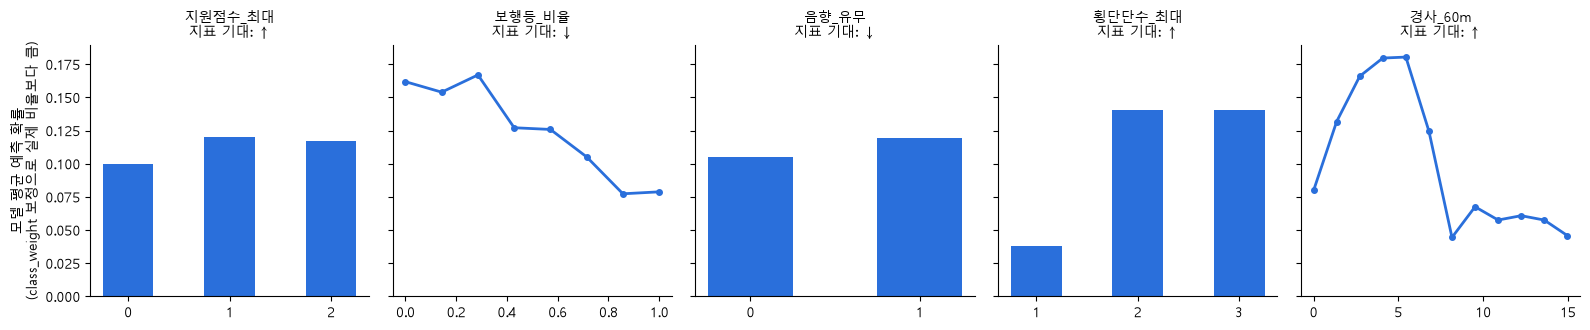

지원점수_최대 {0.0: 0.1, 1.0: 0.12, 2.0: 0.117}
보행등_비율 {0.0: 0.162, 0.14: 0.154, 0.29: 0.167, 0.43: 0.127, 0.57: 0.126, 0.71: 0.105, 0.86: 0.077, 1.0: 0.079}
음향_유무 {0.0: 0.105, 1.0: 0.119}
횡단단수_최대 {1.0: 0.038, 2.0: 0.14, 3.0: 0.14}
경사_60m {0.0: 0.08, 1.36: 0.132, 2.72: 0.166, 4.08: 0.18, 5.44: 0.18, 6.8: 0.125, 8.16: 0.044, 9.52: 0.068, 10.88: 0.058, 12.25: 0.061, 13.61: 0.058, 14.97: 0.046}


In [7]:
full_model = make_models()['HistGB'].fit(g[FULL], y)
expect = {'지원점수_최대': '↑', '보행등_비율': '↓', '음향_유무': '↓', '횡단단수_최대': '↑', '경사_60m': '↑'}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), sharey=True)
pd_rows = {}
for ax, (f, e) in zip(axes, expect.items()):
    grid = None
    if f == '경사_60m':
        grid = np.linspace(0, g[f].quantile(0.95), 12)
        r = partial_dependence(full_model, g[FULL], [f], kind='average', custom_values={f: grid})
    else:
        r = partial_dependence(full_model, g[FULL], [f], kind='average', grid_resolution=8)
    gv, av = r['grid_values'][0], 1 / (1 + np.exp(-r['average'][0]))   # 로그오즈 -> 확률
    pd_rows[f] = pd.Series(av, index=np.round(gv, 2))
    if len(gv) <= 3:
        ax.bar([str(int(v)) for v in gv], av, color=BLUE, width=0.5)
    else:
        ax.plot(gv, av, color=BLUE, lw=2, marker='o', ms=4)
    ax.set_title(f'{f}\n지표 기대: {e}', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('모델 평균 예측 확률\n(class_weight 보정으로 실제 비율보다 큼)')
plt.tight_layout(); plt.savefig(FIG / '3_방향_partial_dependence.png', dpi=150); plt.show()
for f, s in pd_rows.items():
    print(f, s.round(3).to_dict())

## 5. 규칙으로 보기 — 깊이 3 결정 트리

성능용이 아니라, 사고다발지 근처 교차로를 가르는 규칙이 어떤 변수로 만들어지는지 한눈에 보려는 그림이다.

깊이 3 트리 공간 CV: PR-AUC 0.232, ROC-AUC 0.792


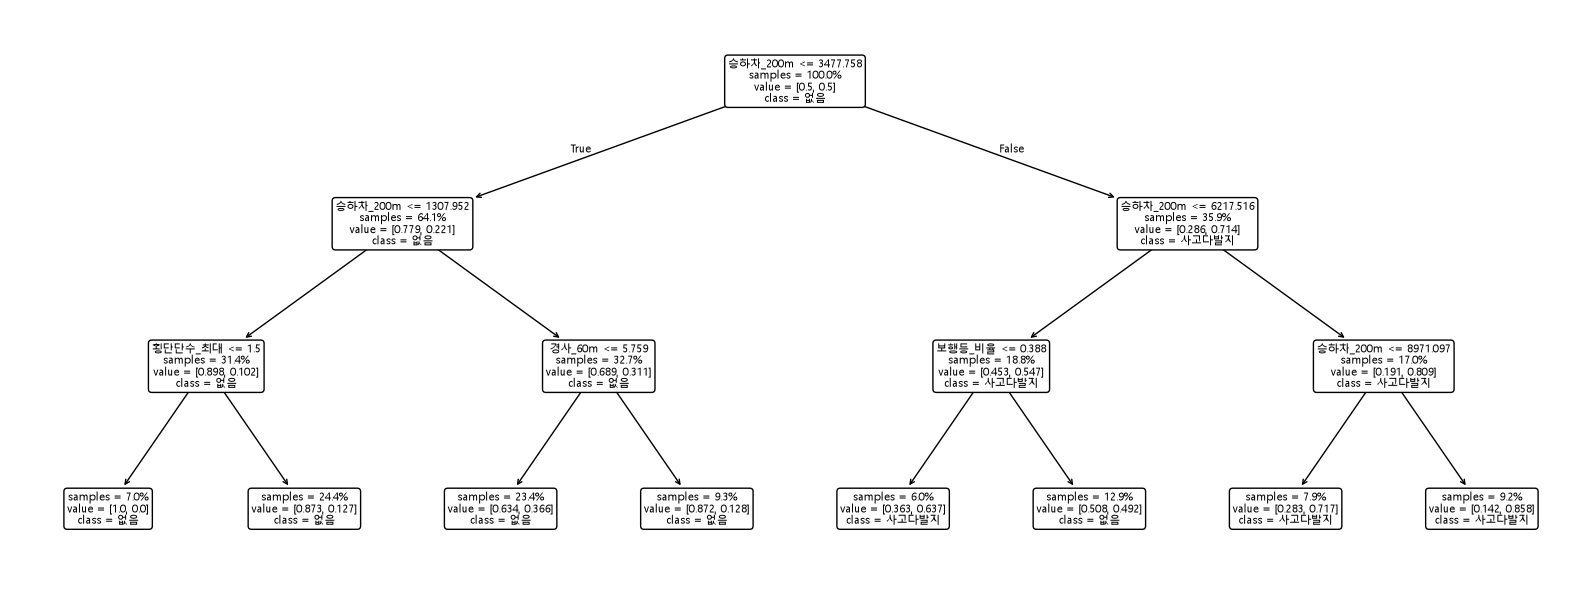

In [8]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, class_weight='balanced', random_state=0)
Xf = g[FULL].fillna(g[FULL].median())
p_tree = cross_val_predict(tree, Xf, y, cv=cv, groups=groups, method='predict_proba')[:, 1]
print(f'깊이 3 트리 공간 CV: PR-AUC {average_precision_score(y, p_tree):.3f}, ROC-AUC {roc_auc_score(y, p_tree):.3f}')
tree.fit(Xf, y)
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree, feature_names=FULL, class_names=['없음', '사고다발지'], filled=False, impurity=False,
          proportion=True, rounded=True, fontsize=8, ax=ax)
plt.tight_layout(); plt.savefig(FIG / '4_결정트리_규칙.png', dpi=150); plt.show()

## 6. 민감도 — 정답 반경 50m / 200m

같은 비교를 반경만 바꿔 반복한다(HistGB·로지스틱).

In [9]:
rows = []
for r in m.LABEL_RADII:
    for inp, feats in [('통제만', m.FEATURES_CTRL), ('통제 + A·B·C', FULL)]:
        s = cv_scores(feats, f'y_{r}m')
        s = s[s['모델'] != 'RandomForest'].groupby('모델')[['PR-AUC', 'ROC-AUC']].mean()
        for mod, v in s.iterrows():
            rows.append({'반경': f'{r}m', '정답 1 비율': f'{g[f"y_{r}m"].mean():.1%}', '모델': mod, '입력': inp,
                         'PR-AUC': v['PR-AUC'], 'ROC-AUC': v['ROC-AUC']})
sens = pd.DataFrame(rows).pivot_table(index=['반경', '정답 1 비율', '모델'], columns='입력', values=['PR-AUC', 'ROC-AUC']).round(3)
sens

PR-AUC           ROC-AUC       
입력                  통제 + A·B·C    통제만 통제 + A·B·C    통제만
반경   정답 1 비율 모델                                        
100m 7.3%    HistGB      0.274  0.286      0.798  0.771
             로지스틱        0.330  0.331      0.822  0.814
200m 13.8%   HistGB      0.413  0.424      0.779  0.779
             로지스틱        0.459  0.457      0.800  0.797
50m  2.8%    HistGB      0.181  0.189      0.816  0.783
             로지스틱        0.220  0.209      0.847  0.835

## 7. 통학로 교차 지점에 적용

두 학교 통학로의 '횡단보도 있음' 교차 지점 61개(숭실대 25, 중앙대 36)에 공간 CV 예측값을 붙인다
(각 교차로가 속한 자치구를 학습에서 뺀 모델의 예측). 교차로관리번호가 여러 개인 지점은 최댓값.

**주의:** A 점수(0~4)의 부족 +1은 반경 500m 사고다발지로 만든 값이라, 사고다발지를 정답으로 배운 모델 예측과 비교하면
같은 정보를 두 번 쓰게 된다. 그래서 깨끗한 비교는 **지원 점수(0~2)** 쪽이고, A 점수 비교는 참고로만 둔다.

매칭 안 된 지점: 0


,지점 수,예측 서울 백분위 중앙값,실제 100m 안 사고다발지 비율,"ρ(지원점수, 예측)","ρ(A점수, 예측) 참고"
학교,,,,,
숭실대,25,0.41,12%,0.35 (p=0.084),"0.61 (n=9, p=0.078)"
중앙대,36,0.55,17%,0.17 (p=0.307),"0.38 (n=26, p=0.057)"
두 학교,61,0.51,15%,0.28 (p=0.028),"0.45 (n=35, p=0.007)"


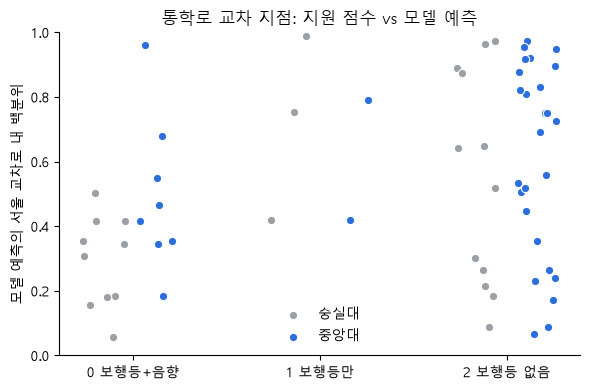

In [10]:
g['예측'] = cross_val_predict(make_models()['HistGB'], g[FULL], y, cv=cv, groups=groups, method='predict_proba')[:, 1]
g['예측_서울백분위'] = g['예측'].rank(pct=True)
rp = m.route_points().merge(g[['교차로관리번호', '예측', '예측_서울백분위', 'y_100m']], on='교차로관리번호', how='left')
pt = rp.groupby(['학교', 'node']).agg(예측=('예측', 'max'), 백분위=('예측_서울백분위', 'max'), 사고다발지_100m=('y_100m', 'max'),
                                     지원점수=('지원점수_최대', 'first'), A점수=('A점수', 'first')).reset_index()
print('매칭 안 된 지점:', int(pt['예측'].isna().sum()))
rows = []
for s, d in list(pt.groupby('학교')) + [('두 학교', pt)]:
    rs = spearmanr(d['지원점수'], d['예측'])
    da = d.dropna(subset=['A점수'])
    ra_ = spearmanr(da['A점수'], da['예측'])
    rows.append({'학교': s, '지점 수': len(d), '예측 서울 백분위 중앙값': round(d['백분위'].median(), 2),
                 '실제 100m 안 사고다발지 비율': f"{d['사고다발지_100m'].mean():.0%}",
                 'ρ(지원점수, 예측)': f'{rs[0]:.2f} (p={rs[1]:.3f})',
                 'ρ(A점수, 예측) 참고': f'{ra_[0]:.2f} (n={len(da)}, p={ra_[1]:.3f})'})
display(pd.DataFrame(rows).set_index('학교'))

fig, ax = plt.subplots(figsize=(6, 4))
for k, (s, d) in enumerate(pt.groupby('학교')):
    jitter = np.random.default_rng(k).uniform(-0.12, 0.12, len(d)) + (k - 0.5) * 0.3
    ax.scatter(d['지원점수'] + jitter, d['백분위'], s=36, color=[GRAY, BLUE][k], label=s, edgecolor='white', lw=0.8)
ax.set_xticks([0, 1, 2], ['0 보행등+음향', '1 보행등만', '2 보행등 없음'])
ax.set_ylabel('모델 예측의 서울 교차로 내 백분위'); ax.set_ylim(0, 1)
ax.set_title('통학로 교차 지점: 지원 점수 vs 모델 예측')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / '5_통학로_적용.png', dpi=150); plt.show()
pt.to_csv(m.OUT_DIR / 'route_points_pred.csv', index=False, encoding='utf-8-sig')

## 8. 해석 (2026-09-25 실행 결과)

### 1) 지표 요소는 보행량 이상의 정보를 거의 더하지 못한다
- 통제 변수만 넣은 모델이 이미 ROC-AUC 0.77~0.81, PR-AUC 0.29~0.33(기준 0.073)이다. 거의 전부 **버스 승하차(보행량 대리)** 덕분이다(중요도 0.18, 다음이 정류소 수 0.04).
- A·B·C 요소를 더해도 PR-AUC는 오르지 않는다(평균 차이 −0.012 ~ −0.001, 5 fold 중 좋아진 fold 1·3·3개). ROC-AUC만 0.01~0.03 오른다.
- A·B·C 요소만 넣으면 무작위보다는 낫지만(PR-AUC 0.10~0.14) 약하다.
- 반경 50m·200m에서도 같은 결론이다.

### 2) 요소별 방향 (partial dependence)
| 요소 | 지표의 기대 | 모델 결과 | 판정 |
|---|---|---|---|
| 보행등_비율 | 높을수록 ↓ | 0.16 → 0.08로 내려감 | 일치 |
| 지원점수_최대 | 0→2 ↑ | 0: 0.10, 1: 0.12, 2: 0.12 (약함) | 약하게 일치 |
| 음향_유무 | 있으면 ↓ | 0.105 → 0.119 (오히려 ↑) | 불일치 — H3와 같은 역인과(위험한 곳에 먼저 설치) |
| 횡단단수_최대 | 이단 ↑ | 일단 0.04 → 이단 0.14 | 일치. 다만 이단은 중앙에 섬을 둘 만큼 넓은 도로라 차량이 많은 효과가 섞여 있을 수 있음 |
| 경사_60m | 가파를수록 ↑ | 5%까지 ↑, 8% 이상은 ↓ | 불일치 — 가파른 곳은 차량·보행량이 적은 주거지 언덕길. 사고는 경사가 시각장애인에게 주는 부담을 반영하지 못함 |

### 3) 통학로 교차 지점 적용 (61개)
- 지원 점수와 모델 예측의 순위상관 ρ = 0.28 (p = 0.028), 약한 양의 관계.
- A 점수와는 ρ = 0.45이지만, A의 부족 +1이 같은 사고다발지로 만든 값이라 **참고용**이다.
- 예측의 서울 백분위 중앙값: 중앙대 0.55, 숭실대 0.41. 중앙대 쪽 횡단 부담이 크다는 A 결과와 같은 방향이지만, 주로 보행량 차이에서 온다.

### 4) 결론 — 이 검증이 말해 주는 것
- 사고다발지로는 A·B·C를 **검증할 수 없다**는 것이 이번 결과의 핵심이다. 사고는 보행량이 거의 결정하고, 음향신호기와 경사는 방향이 반대로 나온다.
- 이는 "A의 순서를 사고 데이터로 정하지 않는다", "A·B·C를 합치지 않는다"는 기존 결정의 근거를 H3에 이어 한 번 더 확인한 것이다.
- 보행등 비율과 이단 횡단은 사고와 같은 방향으로 움직여, A의 지원 점수와 C의 이단 가중치에는 약한 외부 근거가 된다.
- 시각장애인 관점의 타당성은 당사자·전문가 평가 같은 다른 정답이 있어야 검증할 수 있다(시간 부족으로 이번에는 하지 않음).


## 9. 추가 확인 — 로지스틱 회귀 (2026-09-26)

8절 해석 뒤에 "로지스틱을 주 모델로 삼아도 되는가"를 확인하려고 두 가지를 더 했다. 나머지 설정(자치구 5-fold, 정답 반경 100m, 정답 1 비율 7.3%)은 2절과 같다.

1. **승하차_200m 로그 변환:** 승하차는 중앙값 2,392, 최댓값 54,057로 오른쪽 꼬리가 길다. 로지스틱은 값 자체의 크기에 민감하므로 `log1p`로 바꿔 성능이 달라지는지 본다. (HistGB·RandomForest는 값의 순서만 쓰므로 변환해도 결과가 같아 다시 돌리지 않았다.)
2. **로지스틱 계수 표:** 변수를 표준화한 뒤 계수의 부호·크기와, 5개 fold마다 부호가 유지되는지를 본다. 오즈비는 "다른 변수를 고정하고 그 변수가 표준편차 1만큼 커질 때 사고다발지 근처일 오즈가 몇 배가 되는가"이다.

In [3]:
# 9-1. 승하차_200m 로그 변환 (로지스틱만 영향을 받는다. 트리 모델은 값의 순서만 쓰므로 단조 변환에 결과가 같다)
g['log승하차_200m'] = np.log1p(g['승하차_200m'])
CTRL_LOG = ['정류소수_100m', 'log승하차_200m', '교차로수_300m']
FULL_LOG = CTRL_LOG + m.FEATURES_A + m.FEATURES_C + m.FEATURES_B
cv = GroupKFold(n_splits=5)

def logit():
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                         LogisticRegression(class_weight='balanced', max_iter=2000))

def logit_scores(features, label='y_100m'):
    yy = g[label].to_numpy()
    rows = []
    for k, (tr, te) in enumerate(cv.split(g, yy, groups)):
        p = logit().fit(g.iloc[tr][features], yy[tr]).predict_proba(g.iloc[te][features])[:, 1]
        rows.append({'fold': k, 'PR-AUC': average_precision_score(yy[te], p), 'ROC-AUC': roc_auc_score(yy[te], p)})
    return pd.DataFrame(rows)

sets = {('통제만', '원본'): m.FEATURES_CTRL, ('통제만', '로그'): CTRL_LOG,
        ('통제 + A·B·C', '원본'): FULL, ('통제 + A·B·C', '로그'): FULL_LOG,
        ('A·B·C만', '원본'): ACB, ('A·B·C만', '로그'): ACB}   # A·B·C만은 승하차를 안 쓰므로 두 줄이 같다
lres = pd.concat([logit_scores(f).assign(입력=a, 승하차=b) for (a, b), f in sets.items()])
tab = lres.groupby(['입력', '승하차'])[['PR-AUC', 'ROC-AUC']].agg(['mean', 'min', 'max']).round(3)
display(tab.loc[['통제만', '통제 + A·B·C', 'A·B·C만']])

d = lres.pivot_table(index=['승하차', 'fold'], columns='입력', values=['PR-AUC', 'ROC-AUC'])
for metric in ['PR-AUC', 'ROC-AUC']:
    diff = (d[metric]['통제 + A·B·C'] - d[metric]['통제만']).groupby('승하차')
    print(f'{metric} 차이(통제+A·B·C − 통제만):', diff.mean().round(3).to_dict(),
          '| 좋아진 fold 수:', diff.apply(lambda s: int((s > 0).sum())).to_dict())


PR-AUC               ROC-AUC              
                 mean    min    max    mean    min    max
입력         승하차                                           
통제만        로그   0.338  0.250  0.378   0.817  0.808  0.832
           원본   0.331  0.222  0.386   0.814  0.802  0.827
통제 + A·B·C 로그   0.323  0.204  0.403   0.823  0.809  0.830
           원본   0.330  0.204  0.385   0.822  0.802  0.837
A·B·C만     로그   0.135  0.081  0.228   0.646  0.597  0.691
           원본   0.135  0.081  0.228   0.646  0.597  0.691

PR-AUC 차이(통제+A·B·C − 통제만): {'로그': -0.015, '원본': -0.001} | 좋아진 fold 수: {'로그': 2, '원본': 3}
ROC-AUC 차이(통제+A·B·C − 통제만): {'로그': 0.006, '원본': 0.008} | 좋아진 fold 수: {'로그': 4, '원본': 5}


,묶음,계수(전체),오즈비(1SD),fold별 계수 평균,fold별 표준편차,부호 일치 fold(5개 중),지표 기대,방향 판정
보행등_비율,A,-0.316,0.729,-0.316,0.035,5,−,일치
경사_60m,B,-0.214,0.807,-0.214,0.040,5,+,반대
대각선_유무,C,-0.088,0.916,-0.088,0.022,5,—,—
지원점수_최대,A,-0.073,0.929,-0.074,0.022,5,+,반대
교차로수_300m,통제,0.025,1.026,0.021,0.037,4,—,—
음향_유무,A,0.052,1.053,0.051,0.033,5,−,반대
정류소수_100m,통제,0.216,1.240,0.215,0.023,5,—,—
횡단보도수,A,0.234,1.263,0.234,0.029,5,—,—
횡단단수_최대,C,0.245,1.278,0.246,0.042,5,+,일치
log승하차_200m,통제,2.018,7.524,2.033,0.209,5,—,—


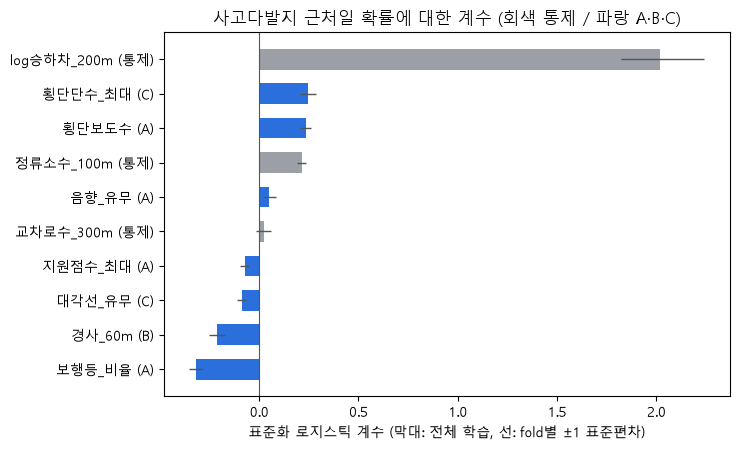

A 요소끼리의 상관(공선성 점검):


,지원점수_최대,보행등_비율,음향_유무,횡단보도수,횡단단수_최대
지원점수_최대,1.00,-0.84,-0.23,0.26,-0.06
보행등_비율,-0.84,1.00,0.36,-0.05,0.22
음향_유무,-0.23,0.36,1.00,0.26,0.31
횡단보도수,0.26,-0.05,0.26,1.00,0.24
횡단단수_최대,-0.06,0.22,0.31,0.24,1.00


In [4]:
# 9-2. 로지스틱 계수 — 다른 변수를 고정했을 때 한 변수가 표준편차 1만큼 커지면 사고다발지 근처일 오즈가 몇 배가 되는가
expect = {'지원점수_최대': '+', '보행등_비율': '−', '음향_유무': '−', '횡단단수_최대': '+', '경사_60m': '+'}
group_of2 = {f: ('통제' if f in CTRL_LOG else 'A' if f in m.FEATURES_A else 'C' if f in m.FEATURES_C else 'B') for f in FULL_LOG}
coefs = []
for tr, te in cv.split(g, y, groups):
    mdl = logit().fit(g.iloc[tr][FULL_LOG], y[tr])
    coefs.append(mdl[-1].coef_[0])
coefs = pd.DataFrame(coefs, columns=FULL_LOG)
full_fit = logit().fit(g[FULL_LOG], y)[-1].coef_[0]
ct = pd.DataFrame({
    '묶음': pd.Series(group_of2),
    '계수(전체)': pd.Series(full_fit, index=FULL_LOG),
    '오즈비(1SD)': np.exp(pd.Series(full_fit, index=FULL_LOG)),
    'fold별 계수 평균': coefs.mean(),
    'fold별 표준편차': coefs.std(),
    '부호 일치 fold(5개 중)': (np.sign(coefs) == np.sign(coefs.mean())).sum(),
    '지표 기대': pd.Series(expect),
}).fillna({'지표 기대': '—'})
ct['방향 판정'] = [('일치' if (e == '+') == (c > 0) else '반대') if e != '—' else '—' for e, c in zip(ct['지표 기대'], ct['계수(전체)'])]
display(ct.sort_values('계수(전체)').round(3))

ordered = ct.sort_values('계수(전체)')
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(ordered.index, ordered['계수(전체)'], color=[GRAY if g_ == '통제' else BLUE for g_ in ordered['묶음']], height=0.6)
ax.errorbar(coefs.mean()[ordered.index], range(len(ordered)), xerr=coefs.std()[ordered.index], fmt='none', ecolor='#555', lw=1)
ax.axvline(0, color='#555', lw=0.8)
ax.set_yticks(range(len(ordered)), [f'{f} ({group_of2[f]})' for f in ordered.index])
ax.set_xlabel('표준화 로지스틱 계수 (막대: 전체 학습, 선: fold별 ±1 표준편차)')
ax.set_title('사고다발지 근처일 확률에 대한 계수 (회색 통제 / 파랑 A·B·C)')
plt.tight_layout(); plt.savefig(FIG / '5_로지스틱_계수.png', dpi=150); plt.show()

print('A 요소끼리의 상관(공선성 점검):')
display(g[m.FEATURES_A + ['횡단단수_최대']].corr(method='spearman').round(2))


### 9-3. 해석 (2026-09-26 실행 결과)

**1) 로그 변환은 결론을 바꾸지 않는다**
- 통제만: PR-AUC 0.331 → 0.338, ROC-AUC 0.814 → 0.817. 통제 + A·B·C: PR-AUC 0.330 → 0.323, ROC-AUC 0.822 → 0.823. 어느 쪽도 fold 범위 안의 차이라 성능 개선이라고 보기 어렵다.
- A·B·C를 더했을 때의 차이도 그대로다. PR-AUC는 −0.015(로그) / −0.001(원본)로 오르지 않고, ROC-AUC는 +0.006 / +0.008로 조금 오른다. 좋아진 fold 수는 PR-AUC 2·3개, ROC-AUC 4·5개(5개 중).
- 그래서 로지스틱을 주 모델로 쓰는 판단은 유지하되, 로그 변환은 필수가 아니다.

**2) 계수: 예측은 보행량이 거의 전부 설명한다**
- `log승하차_200m` 오즈비가 7.5(표준편차 1 증가당)로, 다른 모든 변수(0.73~1.28)보다 훨씬 크다. 정류소수_100m도 1.24다.
- A·B·C 요소의 계수는 모두 −0.32~+0.25 범위라 크기가 작다. 다만 부호는 자치구를 바꿔 학습해도 대부분 5개 fold 모두 같다(교차로수_300m만 4개).

**3) 방향: 지표의 기대와 맞는 것 2개, 반대인 것 3개**
| 요소 | 지표 기대 | 계수 | 판정 |
|---|---|---|---|
| 보행등_비율 | − | −0.316 (오즈비 0.73) | 일치 |
| 횡단단수_최대 | + | +0.245 (1.28) | 일치 |
| 경사_60m | + | −0.214 (0.81) | 반대 |
| 음향_유무 | − | +0.052 (1.05) | 반대(크기는 매우 작음) |
| 지원점수_최대 | + | −0.073 (0.93) | 반대이나 해석 주의 |
- 지원점수_최대는 보행등_비율과 순위상관이 −0.84라, 둘을 함께 넣으면 계수의 부호가 서로 밀려서 나올 수 있다. 8절의 HistGB 결과(약하게 일치)와도 다르므로 이 항목은 해석하지 않는다.
- 음향신호기(위험한 곳에 먼저 설치되는 역인과)와 경사(가파른 곳은 보행량이 적은 주거지 언덕길)가 반대로 나오는 것은 H3·H2·8절과 같은 방향이다.
- 8절에서 "로지스틱은 경사의 비단조 패턴을 못 잡아 '효과 없음'으로 나올 수 있다"고 적었는데, 실제로는 **음의 계수(−0.214)** 로 나왔다. 5%까지 오르는 구간보다 8% 이상에서 내려가는 구간의 영향이 더 크게 반영된 것으로 보이며, 선형 모형이라 경사 하나의 방향으로 요약할 수 없다(경사 구간을 나눠 넣는 확인은 하지 않았다).
- `횡단보도수`는 지표의 기대 방향을 미리 정하지 않았지만 +0.234로, 횡단보도가 많은 교차로(큰 교차로)일수록 사고다발지 근처일 확률이 높다.

**4) 이 결과로 말할 수 있는 것과 없는 것**
- 있는 것: 보행등 비율과 이단 횡단에는 사고 데이터와 같은 방향의 약한 외부 근거가 있고, 그 방향은 자치구를 바꿔도 유지된다. A·B·C를 더하면 ROC-AUC가 소폭 오른다.
- 없는 것: A·B·C가 시각장애인의 불편을 나타낸다는 증명. PR-AUC는 오르지 않고, 음향신호기·경사(·지원점수)는 반대 방향이며, 정답이 시각장애인 전용이 아닌 사고다발지다.
- 부호가 5개 fold에서 같다는 것은 자치구 사이에서 안정적이라는 뜻이지 통계적 유의성이나 인과를 뜻하지 않는다. 학습에 `class_weight='balanced'`를 썼으므로 계수의 절대 크기는 참고로만 본다.

## 10. 추가 검증 — 차도(간선)를 제외하면 경사 방향이 바뀌는가 (2026-09-26)

**배경(팀원 의견):** "경사가 가파를수록 사고다발지 확률이 낮게 나오는 것은, 사고가 주로 나는 차도가 경사가 낮아서일 수 있다."
이 설명이 맞다면 두 가지가 성립해야 한다. ① 사고다발지 근처는 차도(큰 도로)에 몰려 있다 ② 차도 교차로는 다른 곳보다 경사가 낮다.
그리고 차도를 통제하거나 제외하면 경사가 사고다발지와 반대로 나오는 현상이 줄거나 뒤집혀야 한다.

**차도 판정(OSM `highway` 등급).** 교차로 중심 30m 안에 있는 OSM 도로 중 가장 높은 등급으로 나눈다.
`간선` = motorway·trunk·primary·secondary(+link), `보조간선` = tertiary(+link), `그 밖` = 위 등급이 근처에 없음.
residential 이하는 서울 전체를 받으면 자료가 너무 커서 받지 않았으므로 `그 밖`은 "간선·보조간선이 근처에 없다"는 뜻이다.
판정 반경 20·50m와 정답 변형도 함께 확인한다. 제외 단위는 구간이 아니라 **교차로**다(트리 모델의 분석 단위가 교차로이기 때문).

**확인 순서:** 10-1 두 전제 확인 → 10-2 경사 구간별 비율 → 10-3 도로 등급 통제·간선 제외 → 10-4 간선 제외 집합의 공간 교차검증.
처음 결과(도로 등급 통제, 간선 제외)를 본 뒤에 "간선 여부에 따라 경사 효과가 다른지(상호작용)"와 민감도(판정 반경, 정답 변형)를 **추가**했다. 이 추가 분석은 탐색적이다.

In [3]:
# 10-1. 도로 등급 붙이기 + 팀원 가설의 두 전제 확인
import warnings
import statsmodels.formula.api as smf
from scipy.stats import kruskal
import crosswalk_deficiency as cd
import ml_road_class as rc
warnings.filterwarnings('ignore')

roads = rc.fetch_roads(g[['x', 'y']].to_numpy())      # data/tree_model/osm_roads_major_seoul.gpkg가 있으면 다시 받지 않는다
g = rc.add_road_class(g, roads)
LV = '도로등급_30m'                                    # 교차로 중심 30m 안 도로 중 가장 높은 등급(1 간선, 2 보조간선, 3 그 밖)
g['도로등급'] = g[LV].map(rc.LEVEL_LABEL)
ORDER = ['간선', '보조간선', '그 밖']

prem = g.groupby('도로등급').agg(교차로수=('y_100m', 'size'), 사고다발지_근처_수=('y_100m', 'sum'),
                              사고다발지_근처_비율=('y_100m', 'mean'), 경사_중앙값=('경사_60m', 'median'),
                              경사_평균=('경사_60m', 'mean'), 승하차_중앙값=('승하차_200m', 'median')).loc[ORDER]
display(prem.round(3))
print('경사가 등급마다 다른가(Kruskal-Wallis) p =', f"{kruskal(*[g.loc[g[LV] == k, '경사_60m'].dropna() for k in (1, 2, 3)])[1]:.2g}")

acc = cd.load_accidents()
seoul = acc[acc['시도시군구명'].astype(str).str.startswith('서울')]
acc_lv = pd.Series(rc.label_accident_road_class(seoul[['x', 'y']].to_numpy(), roads, 30)).map(rc.LEVEL_LABEL)
print('서울 사고다발지 693곳 자체의 도로 등급(30m 안 최고 등급):', acc_lv.value_counts().reindex(ORDER).to_dict())
print('교차로 도로 등급 분포(20m/30m/50m):',
      {R: g[f'도로등급_{R}m'].map(rc.LEVEL_LABEL).value_counts().reindex(ORDER).to_dict() for R in (20, 30, 50)})


,교차로수,사고다발지_근처_수,사고다발지_근처_비율,경사_중앙값,경사_평균,승하차_중앙값
도로등급,,,,,,
간선,4711,447,0.095,2.955,4.493,3014.194
보조간선,1914,81,0.042,2.234,4.202,1734.242
그 밖,967,25,0.026,3.182,5.477,1354.000


경사가 등급마다 다른가(Kruskal-Wallis) p = 1.4e-15
서울 사고다발지 693곳 자체의 도로 등급(30m 안 최고 등급): {'간선': 400, '보조간선': 86, '그 밖': 207}
교차로 도로 등급 분포(20m/30m/50m): {20: {'간선': 4657, '보조간선': 1936, '그 밖': 999}, 30: {'간선': 4711, '보조간선': 1914, '그 밖': 967}, 50: {'간선': 4796, '보조간선': 1871, '그 밖': 925}}


In [4]:
# 10-2. 경사 구간별 사고다발지 근처 비율 — 전체 / 간선 있음 / 간선 제외
d = g.dropna(subset=['경사_60m']).copy()
d['log승하차'] = np.log1p(d['승하차_200m'])
for c in ['경사_60m', 'log승하차', '정류소수_100m', '교차로수_300m']:
    d[c + '_z'] = (d[c] - d[c].mean()) / d[c].std()
labels = ['2% 이하', '2~5.6%', '5.6~8.3%', '8.3% 초과']
d['경사구간'] = pd.cut(d['경사_60m'], [-0.01, 2, 5.6, 8.3, np.inf], labels=labels)
SETS = {'전체': d[LV] >= 1, '간선 있음': d[LV] == 1, '간선 제외(보조간선+그 밖)': d[LV] >= 2,
        '보조간선만': d[LV] == 2, '그 밖만': d[LV] == 3}
rows = []
for name, mask in SETS.items():
    s = d[mask]
    t = s.groupby('경사구간', observed=True)['y_100m'].agg(['mean', 'sum', 'size'])
    r = spearmanr(s['경사_60m'], s['y_100m'])
    row = {'대상': name, '교차로': len(s), '사고다발지 근처': int(s['y_100m'].sum()), 'ρ(경사, 정답)': f'{r[0]:.3f} (p={r[1]:.2g})'}
    for lab in labels:
        row[lab] = f"{t.loc[lab, 'mean']:.1%} ({int(t.loc[lab, 'sum'])}/{int(t.loc[lab, 'size'])})"
    rows.append(row)
pd.DataFrame(rows).set_index('대상')


,교차로,사고다발지 근처,"ρ(경사, 정답)",2% 이하,2~5.6%,5.6~8.3%,8.3% 초과
대상,,,,,,,
전체,7585,553,-0.050 (p=1.1e-05),8.2% (247/3024),8.7% (213/2436),5.8% (51/877),3.4% (42/1248)
간선 있음,4708,447,-0.075 (p=2.2e-07),11.3% (199/1755),10.6% (175/1644),7.5% (43/572),4.1% (30/737)
간선 제외(보조간선+그 밖),2877,106,-0.018 (p=0.34),3.8% (48/1269),4.8% (38/792),2.6% (8/305),2.3% (12/511)
보조간선만,1911,81,-0.001 (p=0.95),3.9% (35/896),5.8% (32/552),3.9% (7/181),2.5% (7/282)
그 밖만,966,25,-0.035 (p=0.28),3.5% (13/373),2.5% (6/240),0.8% (1/124),2.2% (5/229)


,교차로,사고다발지 근처,경사 계수,오즈비(1SD),95% 하한,95% 상한,p
모형,,,,,,,
① 전체,7585,553,-0.222,0.801,0.669,0.959,0.016
② 전체 + 도로 등급 통제,7585,553,-0.217,0.805,0.676,0.959,0.015
③ 간선 있는 교차로만,4708,447,-0.270,0.763,0.615,0.947,0.014
④ 간선 제외(보조간선+그 밖),2877,106,-0.112,0.894,0.696,1.148,0.380


상호작용(경사 × 간선) 계수 -0.201, 95% 구간 [-0.492, +0.090], p=0.175


,교차로,사고다발지 근처,경사 계수,오즈비(1SD),95% 하한,95% 상한,p
모형,,,,,,,
"간선 제외, 판정 반경 20m",2931,112,-0.121,0.886,0.697,1.125,0.321
"간선 제외, 판정 반경 30m",2877,106,-0.112,0.894,0.696,1.148,0.380
"간선 제외, 판정 반경 50m",2792,100,-0.097,0.908,0.714,1.154,0.428
간선 제외 + 정답에서 간선 위 사고다발지 제외,2877,79,-0.057,0.944,0.752,1.186,0.623


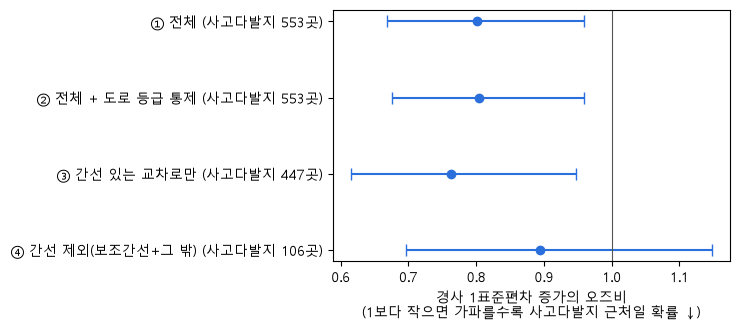

In [5]:
# 10-3. 통제 변수를 넣은 로지스틱(자치구 군집 표준오차) — 경사 1표준편차 증가의 오즈비
ctrl = ' + log승하차_z + 정류소수_100m_z + 교차로수_300m_z'

def logit(s, form):
    return smf.logit(form, data=s).fit(disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(s['자치구'])[0]})

def slope_row(model, s, term='경사_60m_z', label=''):
    ci = model.conf_int().loc[term]
    return {'모형': label, '교차로': len(s), '사고다발지 근처': int(s['y_100m'].sum()), '경사 계수': model.params[term],
            '오즈비(1SD)': np.exp(model.params[term]), '95% 하한': np.exp(ci[0]), '95% 상한': np.exp(ci[1]), 'p': model.pvalues[term]}

base = 'y_100m ~ 경사_60m_z' + ctrl
res = []
m0 = logit(d, base);                                   res.append(slope_row(m0, d, label='① 전체'))
m1 = logit(d, base + ' + C(도로등급_30m)');           res.append(slope_row(m1, d, label='② 전체 + 도로 등급 통제'))
s_major = d[d[LV] == 1]
m3 = logit(s_major, base);                             res.append(slope_row(m3, s_major, label='③ 간선 있는 교차로만'))
s_minor = d[d[LV] >= 2]
m2 = logit(s_minor, base);                             res.append(slope_row(m2, s_minor, label='④ 간선 제외(보조간선+그 밖)'))
tab = pd.DataFrame(res).set_index('모형')
display(tab.round(3))

# 간선 여부에 따라 경사 효과가 정말 다른가: 경사 × 간선 상호작용
d['간선'] = (d[LV] == 1).astype(int)
mi = logit(d, 'y_100m ~ 경사_60m_z * 간선' + ctrl)
ci = mi.conf_int().loc['경사_60m_z:간선']
print(f"상호작용(경사 × 간선) 계수 {mi.params['경사_60m_z:간선']:+.3f}, 95% 구간 [{ci[0]:+.3f}, {ci[1]:+.3f}], p={mi.pvalues['경사_60m_z:간선']:.3f}")

# 민감도: 도로 등급 판정 반경 20m / 50m, 그리고 정답에서 '간선 위 사고다발지'를 뺀 경우
sens = []
for R in (20, 30, 50):
    dm = d[d[f'도로등급_{R}m'] >= 2]
    mm = logit(dm, base)
    r_ = slope_row(mm, dm, label=f'간선 제외, 판정 반경 {R}m'); sens.append(r_)
from scipy.spatial import cKDTree
nonmajor = seoul[pd.Series(rc.label_accident_road_class(seoul[['x', 'y']].to_numpy(), roads, 30)).ne(1).to_numpy()]
d['y_비간선'] = (cKDTree(nonmajor[['x', 'y']].to_numpy()).query(d[['x', 'y']].to_numpy())[0] <= 100).astype(int)
dm = d[d[LV] >= 2]
mm = smf.logit('y_비간선 ~ 경사_60m_z' + ctrl, data=dm).fit(disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(dm['자치구'])[0]})
ci = mm.conf_int().loc['경사_60m_z']
sens.append({'모형': '간선 제외 + 정답에서 간선 위 사고다발지 제외', '교차로': len(dm), '사고다발지 근처': int(dm['y_비간선'].sum()),
             '경사 계수': mm.params['경사_60m_z'], '오즈비(1SD)': np.exp(mm.params['경사_60m_z']),
             '95% 하한': np.exp(ci[0]), '95% 상한': np.exp(ci[1]), 'p': mm.pvalues['경사_60m_z']})
display(pd.DataFrame(sens).set_index('모형').round(3))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
show = tab.iloc[::-1]
ax.errorbar(show['오즈비(1SD)'], range(len(show)), xerr=[show['오즈비(1SD)'] - show['95% 하한'], show['95% 상한'] - show['오즈비(1SD)']],
            fmt='o', color=BLUE, ecolor=BLUE, capsize=4)
ax.axvline(1, color='#555', lw=0.8)
ax.set_yticks(range(len(show)), [f"{i} (사고다발지 {n}곳)" for i, n in zip(show.index, show['사고다발지 근처'])])
ax.set_xlabel('경사 1표준편차 증가의 오즈비\n(1보다 작으면 가파를수록 사고다발지 근처일 확률 ↓)')
plt.tight_layout(); plt.savefig(FIG / '6_차도제외_경사_오즈비.png', dpi=150); plt.show()


In [6]:
# 10-4. 간선 제외 교차로만으로 다시 한 공간 교차검증 (통제만 / 통제 + A·B·C / A·B·C만)
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score

S = g[g[LV] >= 2].reset_index(drop=True).copy()
S['log승하차_200m'] = np.log1p(S['승하차_200m'])
CTRL_L = ['정류소수_100m', 'log승하차_200m', '교차로수_300m']
ABC_L = m.FEATURES_A + m.FEATURES_C + m.FEATURES_B
yS, gS = S['y_100m'].to_numpy(), S['자치구'].to_numpy()
cv5 = GroupKFold(n_splits=5)

def models10():
    return {
        'HistGB': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40,
                                                 class_weight='balanced', random_state=0),
        'RandomForest': make_pipeline(SimpleImputer(strategy='median'),
                                      RandomForestClassifier(500, min_samples_leaf=20, class_weight='balanced', n_jobs=-1, random_state=0)),
        '로지스틱': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                              LogisticRegression(class_weight='balanced', max_iter=2000)),
    }

rows = []
for name, model in models10().items():
    for inp, feats in [('통제만', CTRL_L), ('통제 + A·B·C', CTRL_L + ABC_L), ('A·B·C만', ABC_L)]:
        pr, ro = [], []
        for tr, te in cv5.split(S, yS, gS):
            p = model.fit(S.iloc[tr][feats], yS[tr]).predict_proba(S.iloc[te][feats])[:, 1]
            pr.append(average_precision_score(yS[te], p)); ro.append(roc_auc_score(yS[te], p))
        rows.append({'모델': name, '입력': inp, 'PR-AUC': np.mean(pr), 'PR 최소': min(pr), 'PR 최대': max(pr), 'ROC-AUC': np.mean(ro)})
print(f'간선 제외 교차로 {len(S):,}개, 정답 1 {int(yS.sum())}개, 무작위 기준 PR-AUC {yS.mean():.3f} / ROC-AUC 0.5')
pd.DataFrame(rows).set_index(['모델', '입력']).round(3)


간선 제외 교차로 2,881개, 정답 1 106개, 무작위 기준 PR-AUC 0.037 / ROC-AUC 0.5


PR-AUC  PR 최소  PR 최대  ROC-AUC
모델           입력                                       
HistGB       통제만          0.169  0.059  0.261    0.729
             통제 + A·B·C   0.163  0.067  0.219    0.712
             A·B·C만       0.053  0.028  0.109    0.546
RandomForest 통제만          0.190  0.062  0.305    0.759
             통제 + A·B·C   0.229  0.066  0.310    0.761
             A·B·C만       0.051  0.036  0.087    0.580
로지스틱         통제만          0.208  0.070  0.354    0.789
             통제 + A·B·C   0.219  0.059  0.305    0.774
             A·B·C만       0.077  0.033  0.117    0.620

### 10-5. 해석 (2026-09-26 실행 결과)

**1) 두 전제: 하나는 확인, 하나는 약함**
- ① 사고다발지는 차도(간선)에 몰린다 — **확인됨.** 사고다발지 근처 비율이 간선 9.5% > 보조간선 4.2% > 그 밖 2.6%이고, 서울 사고다발지 693곳 중 400곳(58%)이 간선 30m 안에 있다.
- ② 차도는 경사가 낮다 — **뒷받침이 약함.** 경사 중앙값이 간선 2.96%, 보조간선 2.23%, 그 밖 3.18%다. 등급 사이 차이는 표본이 커서 통계적으로는 유의하지만(p=1.4e-15), 간선이 가장 평평한 것이 아니고(보조간선이 가장 낮음) 간선과 그 밖의 차이는 0.23%p뿐이다.

**2) 도로 등급을 통제하거나 간선을 제외하면**
- 도로 등급을 통제해도 경사 계수가 거의 그대로다(−0.222 → −0.217, 오즈비 0.80, p=0.015). 도로 등급 차이만으로는 경사가 반대로 나온 것이 설명되지 않는다.
- 간선이 있는 교차로만 보면 −0.270(오즈비 0.76, p=0.014)이고, 간선을 제외하면 **−0.112(오즈비 0.89, 95% 구간 0.70~1.15, p=0.38)** 로 절반 아래로 줄고 유의하지 않게 된다. 그러나 **부호가 양(+)으로 뒤집히지는 않는다.**
- 다만 "간선 여부에 따라 경사 효과가 다르다"는 것도 확정되지 않는다. 경사 × 간선 상호작용은 −0.201, 95% 구간 [−0.49, +0.09], p=0.18이다. 간선 제외 집합은 사고다발지 근처 교차로가 106개뿐이라 작은 효과를 가려낼 힘이 부족하다.
- 판정 반경을 20m·50m로 바꾸거나 정답에서 간선 위 사고다발지를 빼도 같은 방향이다(−0.121, −0.097, −0.057, 모두 유의하지 않음).
- 경사 구간별 비율도 간선을 제외한 뒤 전체와 비슷한 모양이다: 2% 이하 3.8%, 2~5.6% 4.8%, 5.6~8.3% 2.6%, 8.3% 초과 2.3%(2~5.6%에서 가장 높고 가파를수록 낮아짐).

**3) 간선 제외 집합의 공간 교차검증 (2,881개, 정답 1 = 106개, 무작위 기준 PR-AUC 0.037)**
- 통제만 → 통제 + A·B·C: PR-AUC HistGB 0.169 → 0.163, RandomForest 0.190 → 0.229, 로지스틱 0.208 → 0.219. ROC-AUC 0.729 → 0.712, 0.759 → 0.761, 0.789 → 0.774. 일관된 개선이 없고 fold마다 PR-AUC가 0.06~0.35로 크게 흔들린다.
- A·B·C만은 PR-AUC 0.05~0.08, ROC-AUC 0.55~0.62로, 전체 교차로에서(ROC-AUC 0.59~0.65)보다 같거나 조금 낮다.

**4) 결론**
- 팀원 의견은 **부분적으로만 확인**됐다. 전제 ①은 맞고 전제 ②는 약하며, 간선을 제외하면 경사 효과가 약해져 통계적으로 사라진다는 점은 의견과 모순되지 않는다. 그러나 도로 등급을 통제해도 계수가 그대로이고, 제외해도 부호가 뒤집히지 않으며, 간선 여부에 따른 차이도 확정되지 않았으므로 **"차도 때문에 경사가 반대로 나왔다"고 결론 내릴 수 없다.** 반대로 "차도 때문이 아니다"라고도 결론 내릴 수 없다(검정력 한계).
- 어느 부분집합에서도 "가파를수록 사고다발지 근처일 확률이 높다"는 방향은 나오지 않았다. 사고 데이터로 B를 정당화할 수 없다는 7-4의 결론은 그대로다.
- 기존 해석("가파른 곳은 차량·보행량이 적은 주거지 언덕길")은 간선이 있는 교차로 안에서도 같은 방향이 나온다는 점에서 도로 등급만으로는 설명되지 않는다. 이 검증으로 그 해석의 옳고 그름을 판단할 수는 없다.

**5) 한계**
- 차도 판정은 OSM 등급뿐이다. residential 이하는 받지 않아 `그 밖`은 "간선·보조간선이 근처에 없다"는 뜻이지 실제 차도가 아니라는 뜻은 아니며, 도로 폭·차로 수·교통량은 없다. 판정은 교차로 중심 30m 규칙에 따른다.
- 제외 단위가 구간이 아니라 교차로이고, 정답이 반경 100m라 이면도로 교차로여도 근처 간선의 사고다발지가 정답으로 잡힌다(간선 제외 교차로의 정답 106개 중 간선 위가 아닌 사고다발지 기준은 79개, 위 민감도에서 확인).
- 간선 제외 집합의 정답이 106개(그 밖만 25개)라 보조간선만·그 밖만의 결과는 해석하지 않는다. 상호작용·민감도는 첫 결과를 본 뒤에 추가한 탐색적 분석이다.
- 정답이 시각장애인의 불편이 아니라 일반 보행자 사고다발지라는 근본 한계, 경사가 60m 기준 절대 경사(±4.7%p 오차)라는 한계는 그대로다.

## 11. 다시 검증 — 차도를 제외하고, 경사가 높은 곳에서 사고가 더 많이 나는가 (2026-09-26)

10절은 "교차로 근처에 사고다발지가 **있는가(있음/없음)**"를 봤다. 이번에는 질문을 두 가지로 바꿔 다시 본다.
- **11-1 지역(격자) 단위:** 차도(간선·보조간선)가 없는 지역만 골라 경사와 사고다발지 수의 관계를 볼 수 있는가.
- **11-2~4 사고다발지 단위:** 사고다발지 각각의 위치에서 경사를 재고, **사고가 얼마나 많은가**(사고건수·중상자·판본 수)가 경사와 관계있는가. 차도 위의 사고다발지와 그렇지 않은 사고다발지를 나눠 본다.

**사고다발지 기록 정리.** 서울 사고다발지 693개는 5개 조사 판본의 기록이라 같은 장소가 여러 번 나온다. 처음에는 `지점코드`로 묶으려 했으나
지점코드는 장소 번호가 아니라 자치구 안의 일련번호여서(같은 코드 안에서도 좌표가 최대 수 km 떨어짐) 쓸 수 없었다. 그래서 **좌표로 30m 안을 같은 장소**로 묶었다
(10m·50m는 민감도). 같은 판본 안에서 서로 다른 장소가 한 덩어리로 합쳐지는 경우는 30m까지 0건이다.

In [3]:
# 11-1. 지역(격자) 단위로 '차도 제외'가 가능한가 — 250m 격자를 도로 등급별로 나눠 사고다발지가 얼마나 있는지
import warnings
import statsmodels.formula.api as smf
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from sklearn.cluster import DBSCAN
from shapely.geometry import box
from shapely.strtree import STRtree
import crosswalk_deficiency as cd
import h5_master
import ml_road_class as rc
warnings.filterwarnings('ignore')

roads = rc.fetch_roads(g[['x', 'y']].to_numpy())
if '도로등급_30m' not in g.columns:
    g = rc.add_road_class(g, roads)
acc = cd.load_accidents()
HR = acc[acc['시도시군구명'].astype(str).str.startswith('서울')].reset_index(drop=True)   # 서울 사고다발지 기록 693개

CELL = 250
gc = g.assign(cx=(g['x'] // CELL).astype(int), cy=(g['y'] // CELL).astype(int))
cells = gc.groupby(['cx', 'cy']).agg(교차로=('x', 'size'), 경사_평균=('경사_60m', 'mean')).reset_index()
polys = [box(cx * CELL, cy * CELL, (cx + 1) * CELL, (cy + 1) * CELL) for cx, cy in zip(cells['cx'], cells['cy'])]
base = roads['highway'].str.replace('_link', '', regex=False)
lvl = np.where(base.isin(rc.MAJOR), 1, np.where(base.isin(rc.MINOR), 2, 3))
cells['도로등급'] = 3
for L in (2, 1):
    idx, _ = STRtree(roads.geometry.to_numpy()[lvl == L]).query(polys, predicate='intersects')
    cells.loc[np.unique(idx), '도로등급'] = L
HR['cx'], HR['cy'] = (HR['x'] // CELL).astype(int), (HR['y'] // CELL).astype(int)
cells = cells.merge(HR.groupby(['cx', 'cy']).size().rename('사고다발지_기록').reset_index(), on=['cx', 'cy'], how='left').fillna({'사고다발지_기록': 0})
t = cells.groupby('도로등급').agg(격자수=('교차로', 'size'), 사고다발지_있는_격자=('사고다발지_기록', lambda s: int((s > 0).sum())),
                                 사고다발지_기록=('사고다발지_기록', 'sum'), 경사_평균=('경사_평균', 'mean'))
t.index = t.index.map(rc.LEVEL_LABEL)
t['기록 비율'] = t['사고다발지_기록'] / t['사고다발지_기록'].sum()
print(f'교차로가 1개 이상 있는 250m 격자 {len(cells):,}개, 그 안의 사고다발지 기록 {int(cells["사고다발지_기록"].sum())}개(전체 693개 중)')
print('격자 등급 = 격자 안을 지나는 도로 중 최고 등급(간선 / 보조간선 / 그 밖)')
t.round(3)


교차로가 1개 이상 있는 250m 격자 4,280개, 그 안의 사고다발지 기록 627개(전체 693개 중)
격자 등급 = 격자 안을 지나는 도로 중 최고 등급(간선 / 보조간선 / 그 밖)


,격자수,사고다발지_있는_격자,사고다발지_기록,경사_평균,기록 비율
도로등급,,,,,
간선,3328,310,589.0,4.433,0.939
보조간선,694,22,32.0,4.866,0.051
그 밖,258,4,6.0,7.081,0.010


In [4]:
# 11-2. 사고다발지 '같은 장소' 정의 — 지점코드는 쓸 수 없고, 좌표로 묶는다
sd = HR.groupby('지점코드')[['x', 'y']].agg(lambda s: s.max() - s.min()).max(axis=1)
print(f'같은 지점코드 안 좌표 최대 차이: 중앙값 {sd.median():,.0f}m, 최대 {sd.max():,.0f}m  → 지점코드는 장소 번호가 아님')
print('조사 판본별 기록 수:', HR['사고다발지id'].value_counts().sort_index().to_dict())
xy_all = HR[['x', 'y']].to_numpy()
rows = []
for eps in (10, 30, 50, 100):
    lab = DBSCAN(eps=eps, min_samples=1).fit_predict(xy_all)
    same = int(HR.assign(c=lab).groupby(['c', '사고다발지id']).size().gt(1).sum())
    rows.append({'묶는 거리': f'{eps}m', '고유 장소 수': len(set(lab)), '같은 판본 안에서 한 덩어리로 합쳐진 경우': same})
pd.DataFrame(rows).set_index('묶는 거리')


같은 지점코드 안 좌표 최대 차이: 중앙값 1,798m, 최대 7,323m  → 지점코드는 장소 번호가 아님
조사 판본별 기록 수: {2022040: 191, 2023060: 134, 2024051: 132, 2025083: 121, 2026122: 115}


,고유 장소 수,같은 판본 안에서 한 덩어리로 합쳐진 경우
묶는 거리,,
10m,623,0
30m,516,0
50m,430,0
100m,338,9


In [5]:
# 11-3. 장소 단위(30m로 묶음) 분석 — 사고다발지 위치의 경사와 사고 규모
b = h5_master.load_bus_stops()
rid = m.bus_ridership(); rid.index = rid.index.astype(str).str.zfill(5)
b['승하차'] = b['ARS_ID'].astype(str).str.zfill(5).map(rid).fillna(0).to_numpy()
bus_tree, bus_ride, int_tree = cKDTree(b[['x', 'y']].to_numpy()), b['승하차'].to_numpy(), cKDTree(g[['x', 'y']].to_numpy())

def build_sites(eps):
    R = HR.copy()
    R['site'] = DBSCAN(eps=eps, min_samples=1).fit_predict(R[['x', 'y']].to_numpy())
    S = R.groupby('site').agg(x=('x', 'mean'), y=('y', 'mean'), 자치구=('시도시군구명', 'first'), 판본수=('사고다발지id', 'nunique'),
                              총사고건수=('사고건수', 'sum'), 평균사고건수=('사고건수', 'mean'), 총중상자=('중상자수', 'sum'),
                              사망발생=('사망자_발생', 'max')).reset_index()
    S['자치구'] = S['자치구'].astype(str).str.replace('서울특별시', '서울').str.strip()
    S = m.add_slope(S)                                              # 교차로와 같은 60m 4방향 최대 경사
    S['등급'] = rc.label_accident_road_class(S[['x', 'y']].to_numpy(), roads, 30)
    xy = S[['x', 'y']].to_numpy()
    S['정류소수_100m'] = [len(v) for v in bus_tree.query_ball_point(xy, 100)]
    S['log승하차'] = np.log1p([bus_ride[v].sum() for v in bus_tree.query_ball_point(xy, 200)])
    S['교차로수_300m'] = [len(v) for v in int_tree.query_ball_point(xy, 300)]
    S = S.dropna(subset=['경사_60m']).copy()
    for c in ['경사_60m', 'log승하차', '정류소수_100m', '교차로수_300m']:
        S[c + '_z'] = (S[c] - S[c].mean()) / S[c].std()
    return S

def poisson_slope(s, y, extra=''):
    r = smf.poisson(f'{y} ~ 경사_60m_z + log승하차_z + 정류소수_100m_z + 교차로수_300m_z' + extra, data=s).fit(
        disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(s['자치구'])[0]})
    ci = r.conf_int().loc['경사_60m_z']
    return {'n': len(s), '배율(1SD)': np.exp(r.params['경사_60m_z']), '95% 하한': np.exp(ci[0]), '95% 상한': np.exp(ci[1]), 'p': r.pvalues['경사_60m_z']}

S30 = build_sites(30)
GRP = {'전체': S30['등급'] >= 1, '간선 위': S30['등급'] == 1, '간선 아님(보조간선+그 밖)': S30['등급'] >= 2}
t = S30.groupby('등급').agg(장소=('x', 'size'), 경사_중앙값=('경사_60m', 'median'), 판본수=('판본수', 'mean'), 총사고건수=('총사고건수', 'mean'),
                          평균사고건수=('평균사고건수', 'mean'), 사망발생비율=('사망발생', 'mean'))
t.index = t.index.map(rc.LEVEL_LABEL)
print(f'좌표 30m로 묶은 사고다발지 장소 {len(S30)}곳 (기록 693개), 판본수 분포 {S30["판본수"].value_counts().sort_index().to_dict()}')
display(t.round(2))

sp = []
for name, mask in GRP.items():
    s = S30[mask]
    row = {'대상': name, '장소': len(s)}
    for c in ['판본수', '총사고건수', '평균사고건수', '총중상자', '사망발생']:
        r_ = spearmanr(s['경사_60m'], s[c]); row[c] = f'{r_[0]:+.2f} (p={r_[1]:.2g})'
    sp.append(row)
print('경사와 사고 규모의 순위상관(Spearman)')
display(pd.DataFrame(sp).set_index('대상'))

pr = []
for y in ['총사고건수', '판본수']:
    for name, mask in GRP.items():
        pr.append({'결과': y, '대상': name, **poisson_slope(S30[mask], y)})
    pr.append({'결과': y, '대상': '전체 + 도로 등급 통제', **poisson_slope(S30, y, ' + C(등급)')})
print('경사 1표준편차 증가당 사고 규모 배율(Poisson, 자치구 군집 표준오차, 보행량·정류소·교차로 밀도 통제). 1보다 크면 가파를수록 사고가 많음')
display(pd.DataFrame(pr).set_index(['결과', '대상']).round(3))

labels = ['2% 이하', '2~5.6%', '5.6~8.3%', '8.3% 초과']
S30['경사구간'] = pd.cut(S30['경사_60m'], [-0.01, 2, 5.6, 8.3, np.inf], labels=labels)
bins = []
for name in ['전체', '간선 아님(보조간선+그 밖)']:
    tt = S30[GRP[name]].groupby('경사구간', observed=True).agg(장소=('x', 'size'), 총사고건수=('총사고건수', 'mean'), 판본수=('판본수', 'mean'))
    tt.index = pd.MultiIndex.from_product([[name], tt.index]); bins.append(tt)
print('경사 구간별 평균')
pd.concat(bins).round(2)


좌표 30m로 묶은 사고다발지 장소 516곳 (기록 693개), 판본수 분포 {1: 384, 2: 97, 3: 28, 4: 4, 5: 3}


,장소,경사_중앙값,판본수,총사고건수,평균사고건수,사망발생비율
등급,,,,,,
간선,299,2.20,1.35,11.01,7.90,0.38
보조간선,66,1.79,1.27,11.00,8.17,0.21
그 밖,151,1.88,1.35,10.74,7.72,0.17


경사와 사고 규모의 순위상관(Spearman)


,장소,판본수,총사고건수,평균사고건수,총중상자,사망발생
대상,,,,,,
전체,516,-0.05 (p=0.28),-0.08 (p=0.058),-0.09 (p=0.049),-0.11 (p=0.014),+0.03 (p=0.53)
간선 위,299,-0.06 (p=0.31),-0.06 (p=0.32),-0.05 (p=0.4),-0.08 (p=0.18),+0.01 (p=0.92)
간선 아님(보조간선+그 밖),217,-0.04 (p=0.57),-0.13 (p=0.049),-0.15 (p=0.033),-0.15 (p=0.024),+0.01 (p=0.83)


경사 1표준편차 증가당 사고 규모 배율(Poisson, 자치구 군집 표준오차, 보행량·정류소·교차로 밀도 통제). 1보다 크면 가파를수록 사고가 많음


n  배율(1SD)  95% 하한  95% 상한      p
결과    대상                                                  
총사고건수 전체               516    0.943   0.893   0.996  0.035
      간선 위             299    0.949   0.884   1.020  0.153
      간선 아님(보조간선+그 밖)  217    0.938   0.867   1.016  0.114
      전체 + 도로 등급 통제    516    0.944   0.893   0.997  0.039
판본수   전체               516    0.968   0.930   1.007  0.107
      간선 위             299    0.964   0.914   1.015  0.165
      간선 아님(보조간선+그 밖)  217    0.973   0.916   1.033  0.363
      전체 + 도로 등급 통제    516    0.968   0.930   1.008  0.119

경사 구간별 평균


장소  총사고건수   판본수
                경사구간                      
전체              2% 이하     253  11.50  1.37
                2~5.6%    182  10.68  1.35
                5.6~8.3%   49   9.29  1.22
                8.3% 초과    32  10.31  1.28
간선 아님(보조간선+그 밖) 2% 이하     117  11.32  1.35
                2~5.6%     68  10.21  1.28
                5.6~8.3%   17  10.76  1.41
                8.3% 초과    15   9.80  1.27

장소 수  배율(1SD)  95% 하한  95% 상한      p
묶는 거리 대상                                         
10m   전체      623    0.978   0.946   1.011  0.186
      간선 위    352    1.000   0.956   1.045  0.983
      간선 아님   271    0.952   0.909   0.998  0.040
30m   전체      516    0.943   0.893   0.996  0.035
      간선 위    299    0.949   0.884   1.020  0.153
      간선 아님   217    0.938   0.867   1.016  0.114
50m   전체      430    0.932   0.868   1.001  0.054
      간선 위    247    0.979   0.884   1.085  0.692
      간선 아님   183    0.879   0.795   0.972  0.012

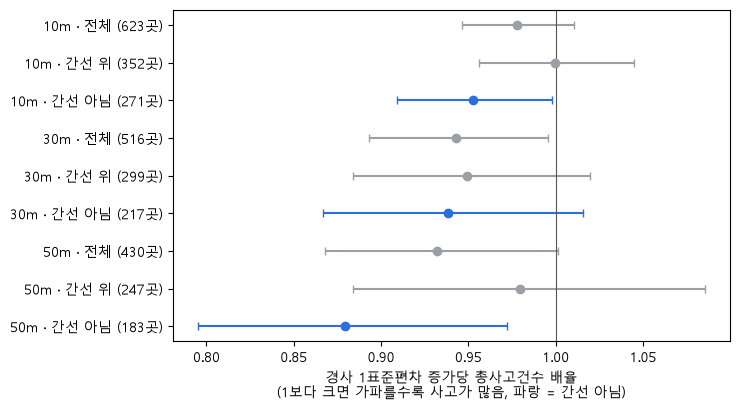

In [6]:
# 11-4. 민감도 — 같은 장소로 묶는 거리를 바꿔도 같은가 (10m / 30m / 50m), 결과: 총사고건수의 경사 배율
sens = []
for eps in (10, 30, 50):
    Se = S30 if eps == 30 else build_sites(eps)
    for name, mask in [('전체', Se['등급'] >= 1), ('간선 위', Se['등급'] == 1), ('간선 아님', Se['등급'] >= 2)]:
        sens.append({'묶는 거리': f'{eps}m', '대상': name, '장소 수': int(mask.sum()), **poisson_slope(Se[mask], '총사고건수')})
sens = pd.DataFrame(sens)
display(sens.drop(columns='n').set_index(['묶는 거리', '대상']).round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ypos, ylab = [], []
for i, (k, r) in enumerate(sens.iloc[::-1].iterrows()):
    ax.errorbar(r['배율(1SD)'], i, xerr=[[r['배율(1SD)'] - r['95% 하한']], [r['95% 상한'] - r['배율(1SD)']]], fmt='o',
                color=BLUE if r['대상'] == '간선 아님' else GRAY, capsize=3)
    ypos.append(i); ylab.append(f"{r['묶는 거리']} · {r['대상']} ({r['장소 수']}곳)")
ax.axvline(1, color='#555', lw=0.8)
ax.set_yticks(ypos, ylab)
ax.set_xlabel('경사 1표준편차 증가당 총사고건수 배율\n(1보다 크면 가파를수록 사고가 많음, 파랑 = 간선 아님)')
plt.tight_layout(); plt.savefig(FIG / '7_사고다발지_경사_사고규모.png', dpi=150); plt.show()


### 11-5. 해석 (2026-09-26 실행 결과)

**1) 지역(격자) 단위로는 차도를 제외한 검증이 불가능하다.** 250m 격자 중 간선이 지나는 격자에 사고다발지 기록의 94%(589/627)가 몰려 있고, 간선이 없는 격자(보조간선만 또는 그 밖)의 사고다발지 기록은 38개(6%)뿐이다(보조간선만 32개, 그 밖 6개). 차도를 제외하면 지역 단위 비교에 쓸 사고가 거의 남지 않는다. 사고다발지 자체가 큰 도로가 있는 곳에 몰린다는 뜻이기도 하다.

**2) 사고다발지 "같은 장소" 정의.** 서울 사고다발지 693개는 기록이고, 같은 장소가 여러 조사 판본에 다시 나온다. `지점코드`는 장소 번호가 아니어서(같은 코드 안에서 좌표가 중앙값 1.8km, 최대 7.3km 차이) 쓸 수 없었다. 좌표 30m로 묶으면 **516곳**(1회 384, 2회 97, 3회 28, 4회 4, 5회 3)이 되고, 같은 판본 안에서 서로 다른 장소가 합쳐지는 경우는 없다. 693개 기록을 그대로 쓰면 같은 장소가 여러 번 세어져 유의성이 부풀려지므로 장소 단위로만 해석한다.

**3) 차도가 아닌 사고다발지에서도 경사가 높다고 사고가 더 많지는 않다.**
- 간선 위 299곳 / 간선이 아닌 217곳(보조간선 66 + 그 밖 151) 어디서도 경사 1표준편차 증가당 총사고건수 배율이 1을 넘지 않는다: 간선 위 0.95(p=0.15), **간선 아님 0.94(95% 구간 0.87~1.02, p=0.11)**, 전체 0.94(p=0.035). 도로 등급을 통제해도 같다(0.944).
- 순위상관도 같은 방향이다. 간선 아님에서 경사와 총사고건수 −0.13(p=0.049), 총중상자 −0.15(p=0.024). 경사 구간별 평균 총사고건수(간선 아님)는 2% 이하 11.3 → 2~5.6% 10.2 → 5.6~8.3% 10.8 → 8.3% 초과 9.8이다.
- 여러 조사에 반복해 뽑힌 정도(판본 수, −0.04, p=0.57)와 사망 발생(+0.01, p=0.83)은 경사와 관계가 없다.

**4) 같은 장소로 묶는 거리를 바꾸면** 간선 아님의 배율이 10m 0.952(p=0.040), 30m 0.938(p=0.114), 50m 0.879(p=0.012)이고, 전체는 0.978, 0.943, 0.932다. **방향은 늘 1 이하이고 1을 넘는 경우는 없지만, 유의성은 정의에 따라 p=0.01~0.11 사이로 흔들려서 "가파를수록 사고가 적다"도 견고하다고는 할 수 없다.**

**5) 결론**
- 차도를 제외해도 **경사가 높은 곳에서 사고가 더 많이 난다는 근거는 없다.** 사고가 있는지(10절, 교차로 단위: 간선 제외 오즈비 0.89, p=0.38)와 사고가 얼마나 많은지(11절, 장소 단위: 간선 아님 배율 0.94, p=0.11) 모두 같은 방향(약한 음의 관계 또는 관계 없음)이다.
- 그러므로 사고 데이터로 B(경사)를 정당화할 수 없다는 7-4의 결론은 그대로다. 차도 때문에 반대로 나왔다는 설명도, 경사가 사고를 줄인다는 설명도 이 자료로는 확정할 수 없다.

**6) 한계**
- 사고다발지는 사고 7건 이상만 선별된 자료라 사고건수가 7~22(평균 8.1)로 좁게 몰려 있어, 사고 규모의 차이를 보기 어렵다. 사고다발지 밖이 안전하다는 뜻도 아니다. 사고 규모는 "사고다발지 안에서의 규모"이지 경사가 사고 발생을 늘리는지를 직접 재는 것이 아니다.
- 총사고건수는 판본별 사고건수의 합이라 여러 판본에 나온 장소일수록 커진다(판본 수는 따로 확인).
- 같은 장소를 좌표 30m로 묶은 것과 차도를 OSM 등급 30m로 판정한 것은 연구자의 선택이다(residential 이하 미수집, 도로 폭·차로 수·교통량 없음). 사고다발지 좌표는 반경 약 80m 원의 중심이라 위치 오차가 수십 m일 수 있다.
- 자치구 25개 단위 군집 표준오차를 썼고 표본이 217곳이라 검정력이 낮다. 여러 결과·정의를 나열해 본 탐색적 분석이므로 p 값이 경계에 있는 것은 확정된 차이로 읽지 않는다.
- 경사는 60m 기준 절대 경사(±4.7%p 오차)이고, 보행량은 버스 승하차로만 통제했다. 정답이 시각장애인의 불편이 아니라는 근본 한계도 그대로다.